In [56]:
import os
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Plot simulation

In [119]:
num_hosts = 16
nodes = 16 # This is the nodes used for greedy local algorithm, 1 if global
processors_per_host = 36
processors = num_hosts * processors_per_host

grouping = "123456"

test_name = f"greedy/c48_p{processors}"

if nodes > 1:
    test_name += f"_h{nodes}"
    if grouping:
        if grouping.isdigit():
            seed = int(grouping)
            path = None
            test_name += f"_s{seed}"
        else:
            seed = 0
            path = Path(grouping)
            test_name += f"_f{path.stem}"
    else:
        seed = 0
        path = None

test_name

'greedy/c48_p576_h16_s123456'

In [121]:
simulation_data_path = f"test/{test_name}/simulation.csv"
simulation_data = pd.read_csv(simulation_data_path, index_col=0)
# Exclude the last four columns and select only numeric columns
simulation_data = simulation_data.iloc[:, :-4].select_dtypes(include=[np.number])
simulation_data

,Processor0,Processor1,Processor2,Processor3,Processor4,Processor5,Processor6,Processor7,Processor8,Processor9,...,Processor566,Processor567,Processor568,Processor569,Processor570,Processor571,Processor572,Processor573,Processor574,Processor575
Interval,,,,,,,,,,,,,,,,,,,,,
0,5138.0,5058.0,4959.0,4585.0,4677.0,6101.0,4803.0,5256.0,4815.0,5145.0,...,4484.0,4888.0,5339.0,6031.0,5027.0,5249.0,5194.0,5097.0,4743.0,4920.0
1,4717.0,4517.0,4073.0,3964.0,4375.0,4954.0,4155.0,4025.0,4337.0,4017.0,...,4033.0,4267.0,4857.0,4745.0,4172.0,4528.0,4681.0,4289.0,3806.0,3911.0
2,4815.0,3852.0,4179.0,3798.0,4138.0,4699.0,3741.0,3811.0,4206.0,3784.0,...,3773.0,4081.0,4411.0,4668.0,4015.0,4097.0,4360.0,4050.0,3636.0,3755.0
3,4820.0,3887.0,3956.0,3755.0,4053.0,4219.0,3723.0,3741.0,4031.0,3652.0,...,3671.0,4117.0,4207.0,5392.0,3915.0,4283.0,4181.0,4009.0,3548.0,3628.0
4,5192.0,3666.0,4023.0,3662.0,4062.0,4210.0,3632.0,3632.0,4041.0,3587.0,...,3558.0,4195.0,4275.0,5064.0,3823.0,4331.0,4364.0,3815.0,3584.0,3486.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,3899.0,4186.0,4298.0,4260.0,3841.0,4769.0,4706.0,4754.0,4128.0,4374.0,...,3727.0,4831.0,4696.0,4356.0,4158.0,4612.0,5076.0,4185.0,4038.0,4747.0
500,3862.0,4118.0,4229.0,4230.0,3835.0,4765.0,4518.0,4725.0,3956.0,4264.0,...,3853.0,4868.0,4546.0,4793.0,4587.0,4539.0,4490.0,4147.0,3958.0,4641.0
501,3877.0,4030.0,4181.0,4338.0,3815.0,5017.0,4481.0,4416.0,3914.0,4096.0,...,3677.0,4947.0,5668.0,5042.0,4670.0,4699.0,5318.0,4115.0,4048.0,4519.0


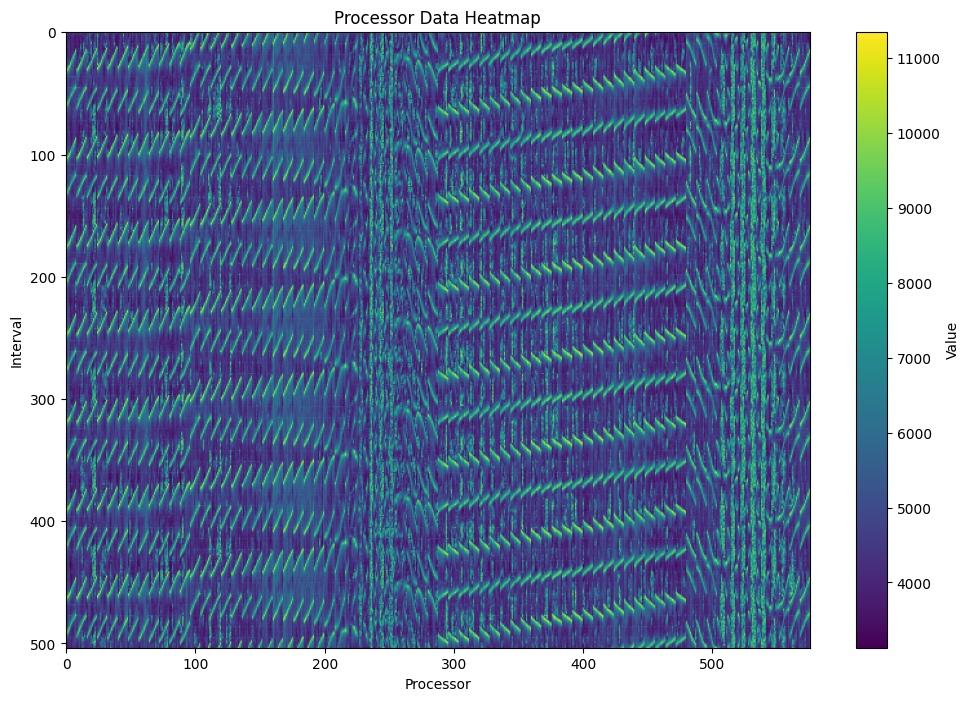

In [122]:
# Plot the simulation data as a heatmap,
def plot_simulation_heatmap(data: pd.DataFrame, heatmap_type: str = "processor", path: Optional[str] = None):
    """
    Plot a heatmap of the simulation data.
    Args:
        data (pd.DataFrame): The data to plot.
        heatmap_type (str): Label for the x-axis (e.g., 'processor', 'node').
        path (Optional[str]): If provided, save the plot to this directory.
    """
    plt.figure(figsize=(12, 8))
    cax = plt.imshow(data, aspect="auto", cmap="viridis")
    plt.colorbar(cax, label="Value")
    plt.xlabel(heatmap_type.capitalize())
    plt.ylabel("Interval")
    plt.title(f"{heatmap_type.capitalize()} Data Heatmap")
    if path:
        os.makedirs(path, exist_ok=True)
        plt.savefig(f"{path}/{heatmap_type}_heatmap.png")
        plt.savefig(f"{path}/{heatmap_type}_heatmap.eps")
    plt.show()

# Plot the simulation data heatmap
plot_simulation_heatmap(
    simulation_data, heatmap_type="processor", path=f"test/plots/{test_name}"
)

Generate random grouping or read from input file

In [123]:
def generate_group_from_seed(
    num_hosts: int, processors_per_host: int, seed: int = 0
 ) -> pd.DataFrame:
    """
    Generate processor groups based on a seed value.
    Args:
        seed (int): Seed for random number generator.
        num_hosts (int): Number of hosts.
        processors_per_host (int): Number of processors per host.
    Returns:
        pd.DataFrame: DataFrame with processor groups.
    """
    processors = num_hosts * processors_per_host
    indices = np.arange(processors)
    if seed:
        np.random.seed(seed)
        np.random.shuffle(indices)
    processor_groups = [
        list(indices[i * processors_per_host : (i + 1) * processors_per_host])
        for i in range(num_hosts)
    ]
    return pd.DataFrame(processor_groups)

if path:
    node_df = pd.read_csv(path, header=None)
else:
    node_df = generate_group_from_seed(num_hosts, processors_per_host, seed)
node_df

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,323,109,236,564,118,168,425,189,499,500,...,291,549,476,448,28,132,44,407,284,296
1,457,33,172,287,48,158,94,248,269,135,...,198,295,418,491,114,518,392,233,545,471
2,47,483,461,155,170,24,117,46,22,565,...,176,321,497,2,121,308,199,294,161,377
3,187,378,453,169,197,87,245,90,566,110,...,128,416,66,366,45,183,399,70,253,408
4,103,541,368,190,320,351,278,531,177,219,...,217,354,464,38,332,385,82,575,148,369
5,312,149,530,185,520,511,559,443,89,389,...,196,35,1,11,31,78,535,111,428,74
6,446,474,8,113,521,257,396,337,341,220,...,383,422,37,544,137,401,547,393,431,258
7,265,255,537,373,60,514,561,551,334,222,...,10,357,398,144,52,469,249,339,509,479
8,363,447,492,467,358,76,19,221,99,335,...,251,442,203,95,116,7,355,232,423,466
9,263,39,451,107,100,102,63,327,81,231,...,214,523,20,343,374,256,463,34,238,472


Plot group's total simulated workload

In [124]:
dynamic_node_mapping = {}
for group_id, row in node_df.iterrows():
    for processor_id in row:
        dynamic_node_mapping[f"Processor{processor_id}"] = f"Group{group_id}"
print(dynamic_node_mapping)

{'Processor323': 'Group0', 'Processor109': 'Group0', 'Processor236': 'Group0', 'Processor564': 'Group0', 'Processor118': 'Group0', 'Processor168': 'Group0', 'Processor425': 'Group0', 'Processor189': 'Group0', 'Processor499': 'Group0', 'Processor500': 'Group0', 'Processor342': 'Group0', 'Processor36': 'Group0', 'Processor522': 'Group0', 'Processor557': 'Group0', 'Processor493': 'Group0', 'Processor98': 'Group0', 'Processor227': 'Group0', 'Processor229': 'Group0', 'Processor571': 'Group0', 'Processor468': 'Group0', 'Processor225': 'Group0', 'Processor54': 'Group0', 'Processor123': 'Group0', 'Processor254': 'Group0', 'Processor438': 'Group0', 'Processor318': 'Group0', 'Processor291': 'Group0', 'Processor549': 'Group0', 'Processor476': 'Group0', 'Processor448': 'Group0', 'Processor28': 'Group0', 'Processor132': 'Group0', 'Processor44': 'Group0', 'Processor407': 'Group0', 'Processor284': 'Group0', 'Processor296': 'Group0', 'Processor457': 'Group1', 'Processor33': 'Group1', 'Processor172': '

In [125]:
# Rename columns in workload_df using the dynamic node mapping
dynamic_grouped_df = simulation_data.rename(columns=dynamic_node_mapping)
# Sum workload by group
dynamic_summed_df = dynamic_grouped_df.T.groupby(level=0).sum().T
dynamic_summed_df

,Group0,Group1,Group10,Group11,Group12,Group13,Group14,Group15,Group2,Group3,Group4,Group5,Group6,Group7,Group8,Group9
Interval,,,,,,,,,,,,,,,,
0,220144.0,188830.0,222164.0,221328.0,227148.0,211338.0,246410.0,238382.0,206523.0,209149.0,210705.0,211064.0,194081.0,211250.0,192563.0,206541.0
1,205207.0,152273.0,204780.0,198477.0,209576.0,198150.0,215863.0,216872.0,199694.0,186495.0,180708.0,191277.0,176445.0,192760.0,170687.0,173061.0
2,203160.0,143069.0,208989.0,186215.0,207152.0,202994.0,197763.0,209610.0,208098.0,176788.0,170509.0,190664.0,175085.0,179420.0,162681.0,164632.0
3,201395.0,148314.0,223602.0,177007.0,217801.0,204661.0,187466.0,203280.0,204579.0,169375.0,169598.0,188146.0,174469.0,170565.0,155763.0,166195.0
4,202159.0,161614.0,241695.0,175654.0,225578.0,194900.0,179716.0,199422.0,196354.0,169798.0,176264.0,178630.0,169280.0,163698.0,150613.0,169820.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,210444.0,216253.0,192942.0,187660.0,205987.0,182657.0,201803.0,198840.0,193797.0,168541.0,180702.0,200143.0,187666.0,188912.0,223977.0,193532.0
500,197832.0,206815.0,193529.0,185376.0,201263.0,182995.0,208937.0,192794.0,186905.0,174294.0,195066.0,201020.0,191137.0,193018.0,217904.0,177393.0
501,194838.0,197541.0,195258.0,184173.0,199659.0,182712.0,212271.0,197204.0,175886.0,185812.0,203062.0,197934.0,190983.0,198439.0,202494.0,168275.0


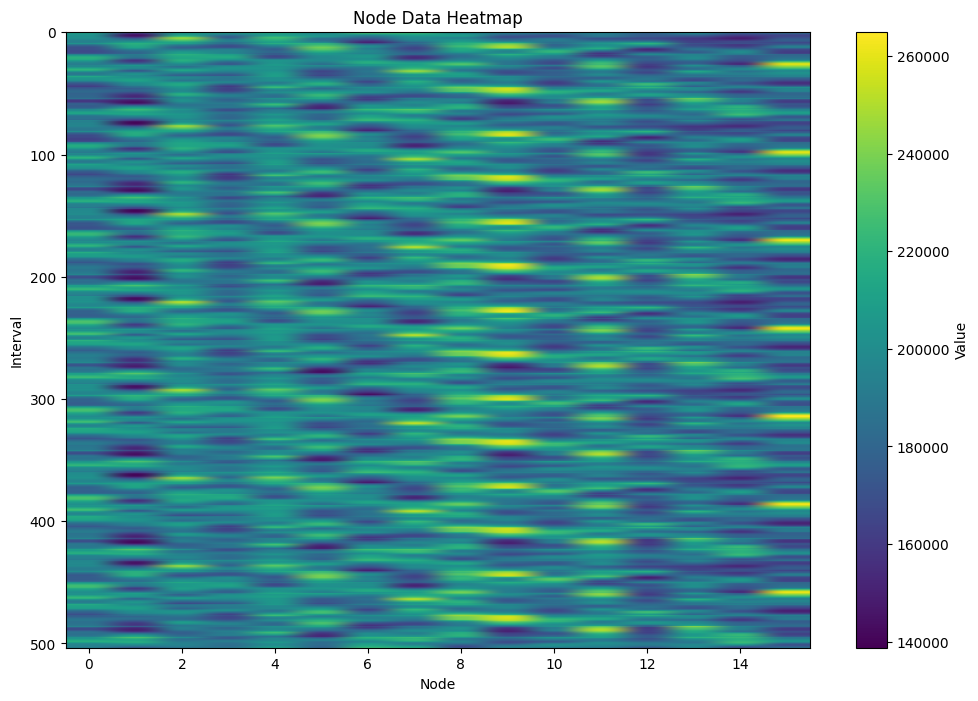

In [126]:
plot_simulation_heatmap(dynamic_summed_df, heatmap_type="node", path=f"test/plots/{test_name}")